# Models

This file contains multiple models applied on the dataset
The code contains mistakes and generates comparisons between the wrong features (columns from the csv)
Your job is to use `data_analysis.ipynb` to find the correct relationships to achieve maximum accuracy 

## Definitions

**Imports:**

In [41]:
# Standard library
import json
import os
import warnings

# Suppress convergence warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Third-party
import joblib
import matplotlib.pyplot as plt
import pandas as pd

# Scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

**Helper functions to use in later blocks:**

In [42]:
def _to_json_serializable(value):
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    if hasattr(value, "item") and callable(getattr(value, "item")):
        try:
            return value.item()
        except Exception:
            pass
    if isinstance(value, dict):
        return {str(k): _to_json_serializable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_to_json_serializable(v) for v in value]
    return str(value)


def evaluate_model(model_name, hyperparameters, feature_cols):
    MODEL_DIR = "../models"
    model_path = os.path.join(MODEL_DIR, model_name + ".joblib")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")

    model = joblib.load(model_path)

    global X_test, y_test

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Evaluation metrics for {model_name}:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R^2: {r2:.4f}")

    METRICS_PATH = os.path.join(MODEL_DIR, "model_metrics.json")
    metrics = {}
    if os.path.exists(METRICS_PATH):
        with open(METRICS_PATH, "r") as f:
            metrics = json.load(f)

    metrics[model_name] = {
        "MSE": float(mse),
        "MAE": float(mae),
        "R2": float(r2),
        "hyperparameters": _to_json_serializable(hyperparameters),
        "feature_columns": list(feature_cols),
    }

    with open(METRICS_PATH, "w") as f:
        json.dump(metrics, f, indent=4)

    return y_pred


def plot_predictions(y_true, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual " + target_column)
    plt.ylabel("Predicted " + target_column)
    plt.title(f"Predicted vs Actual Values ({model_name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Read Data

In [ ]:
# read the csv file
df = pd.read_csv("../data/dataset.csv")

target_column = "power_consumption" # do not change this line

feature_columns = ["disk_io", "thread_count", "temperature"]  # change

# Prepare data
X = df[feature_columns]
y = df[target_column]

# split data for train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# constants
model_name = ""
MODEL_DIR = "../models"

## Polynomial Regression

Evaluation metrics for polynomial_regression:
MSE: 16555.2445
MAE: 103.6879
R^2: 0.1962


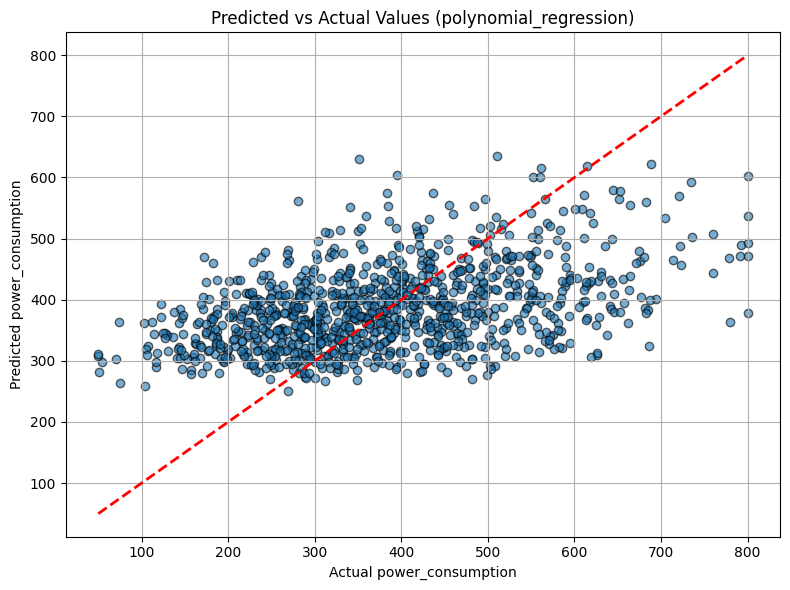

In [44]:
# Model save directory
model_name = "polynomial_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
degree = 2              # Polynomial degree for feature expansion
include_bias = False    # Whether to include bias term in polynomial features

hyperparameters = {
    "degree": degree,
    "include_bias": include_bias,
}

# Training model
model = make_pipeline(PolynomialFeatures(degree, include_bias=include_bias), LinearRegression())
model.fit(X_train, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters, feature_columns)
plot_predictions(y_test, predictions, model_name)

## Random Forest Regression

Evaluation metrics for random_forest_regression:
MSE: 17132.9291
MAE: 105.9075
R^2: 0.1682


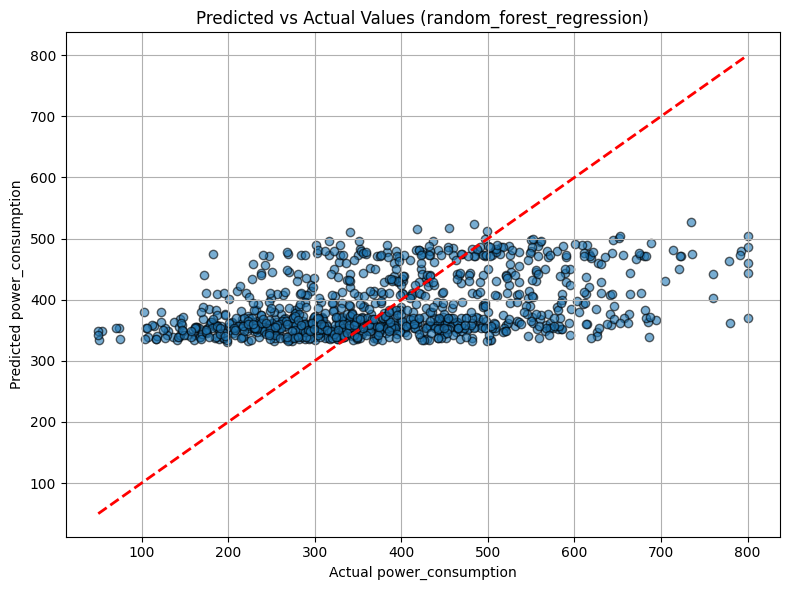

In [45]:
# Model save directory
model_name = "random_forest_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
n_estimators = 10       # Number of trees in the forest
max_depth = 3           # Maximum depth of each tree
min_samples_split = 50  # Minimum samples required to split a node
min_samples_leaf = 20   # Minimum samples required at each leaf node
max_features = 0.3      # Number of features to consider for best split
random_state = 42       # Random seed for reproducibility

hyperparameters = {
    "n_estimators": n_estimators,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
    "max_features": max_features,
    "random_state": random_state,
    "n_jobs": -1,
}

# Training model
model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    max_features=max_features,
    random_state=random_state,
    n_jobs=-1,
)
model.fit(X_train, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters, feature_columns)
plot_predictions(y_test, predictions, model_name)

## Multi-Layer Perceptron Regression

Evaluation metrics for mlp_regressor:
MSE: 16512.3241
MAE: 103.4769
R^2: 0.1983


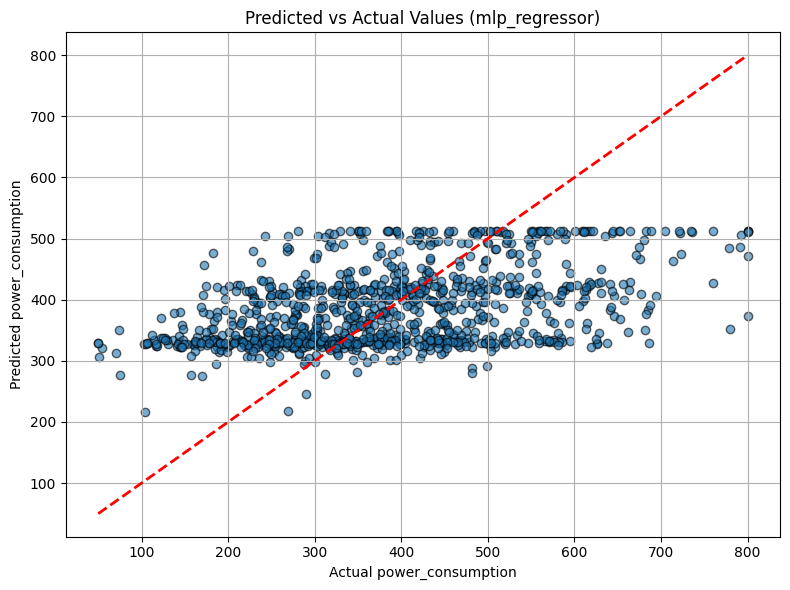

In [46]:
# Model save directory
model_name = "mlp_regressor"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
hidden_layer_sizes = (10,)      # Number of neurons in each hidden layer
activation = "tanh"             # Activation function for hidden layers
solver = "sgd"                  # Optimizer algorithm
max_iter = 100                  # Maximum training iterations
random_state = 42               # Random seed for reproducibility
alpha = 0.1                     # L2 regularization strength
learning_rate_init = 0.0001     # Initial learning rate
early_stopping = False          # Stop training when validation score stops improving

hyperparameters = {
    "hidden_layer_sizes": hidden_layer_sizes,
    "activation": activation,
    "solver": solver,
    "max_iter": max_iter,
    "random_state": random_state,
    "alpha": alpha,
    "learning_rate_init": learning_rate_init,
    "early_stopping": early_stopping,
    "scaled": True,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        early_stopping=early_stopping,
        random_state=random_state,
    ),
)
model.fit(X_train, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters, feature_columns)
plot_predictions(y_test, predictions, model_name)

## Support Vector Regression

Evaluation metrics for svr_regressor:
MSE: 19222.6598
MAE: 111.5778
R^2: 0.0667


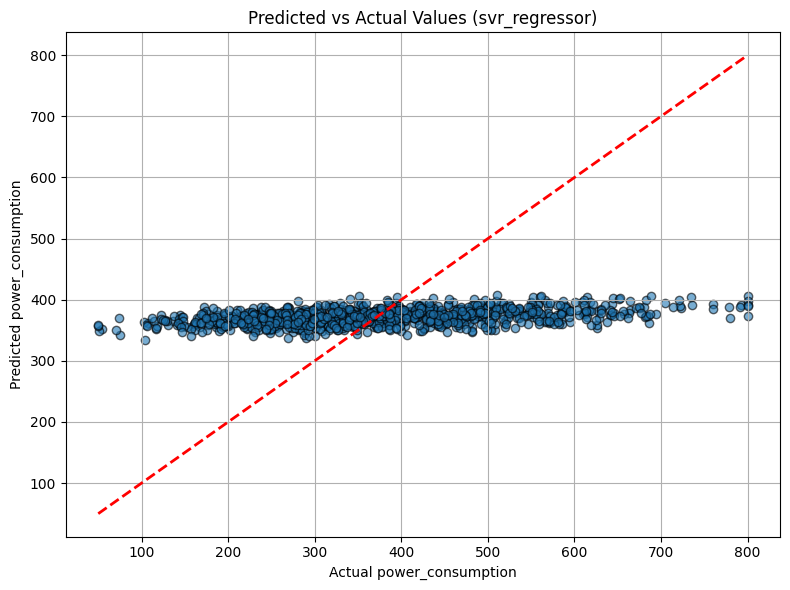

In [47]:
# Model save directory
model_name = "svr_regressor"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
kernel = "linear"       # Kernel type for mapping to higher dimensions
C = 0.01                # Regularization parameter
epsilon = 1.0           # Epsilon-tube width for no penalty zone
gamma = "scale"         # Kernel coefficient

hyperparameters = {
    "kernel": kernel,
    "C": C,
    "epsilon": epsilon,
    "gamma": gamma,
    "scaled": True,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma),
)
model.fit(X_train, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters, feature_columns)
plot_predictions(y_test, predictions, model_name)

## Elastic Net

Evaluation metrics for elastic_net_regression:
MSE: 17917.4375
MAE: 108.6719
R^2: 0.1301


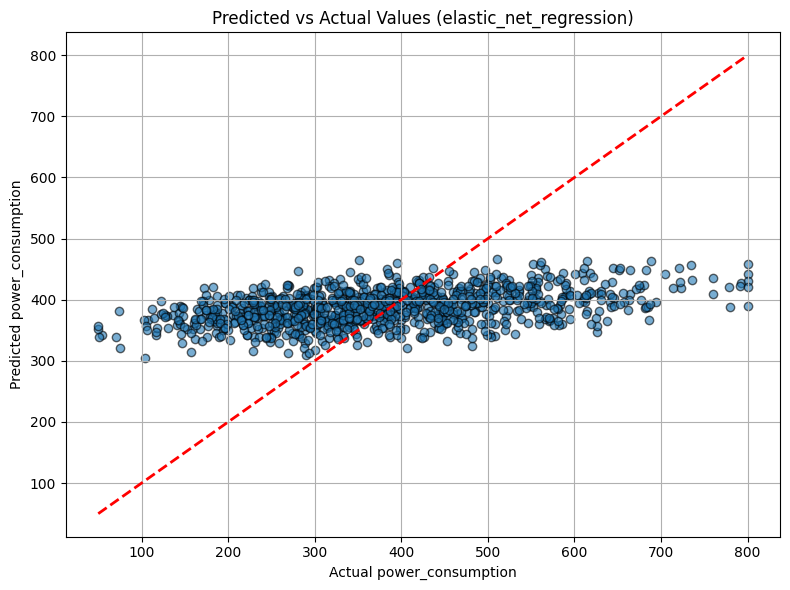

In [48]:
# Model save directory
model_name = "elastic_net_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
alpha = 10.0            # Regularization strength
l1_ratio = 0.9          # Mix ratio between L1 and L2 regularization
max_iter = 100          # Maximum training iterations
random_state = 42       # Random seed for reproducibility

hyperparameters = {
    "alpha": alpha,
    "l1_ratio": l1_ratio,
    "max_iter": max_iter,
    "random_state": random_state,
    "scaled": True,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=max_iter, random_state=random_state),
)
model.fit(X_train, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters, feature_columns)
plot_predictions(y_test, predictions, model_name)